In [27]:
from Bio import SeqIO
from tqdm import tqdm
import matplotlib.pyplot as plt

In [14]:
HS = str(SeqIO.read("//Users/arina.anurieva/Downloads/NC_012920.1.fasta", "fasta").seq)
HSA = str(SeqIO.read("/Users/arina.anurieva/Downloads/NC_011137.1.fasta", "fasta").seq)

len(HS), len(HSA)

(16569, 16565)

In [16]:
def naive(first, second, window_size):
    first_match_coords = []
    second_match_coords = []
    
    for i in tqdm(range(len(first) - window_size + 1), "first"):
        window_first = first[i:i+window_size]
        
        for j in range(len(second) - window_size + 1):
            window_second = second[j:j+window_size]
            matches = sum(1 for a, b in zip(window_first, window_second) if a == b) 
            if matches >= window_size:
                first_match_coords.append(i)
                second_match_coords.append(j)
    return first_match_coords, second_match_coords

In [18]:
def naive_inv(first, second, window_size):
    first_match_coords = []
    second_match_coords = []
    
    for i in tqdm(range(len(first) - window_size + 1), "first"):
        window_first = first[i:i+window_size]
        
        for j in range(len(second) - window_size + 1):
            window_second = second[j+window_size:j:-1]
            matches = sum(1 for a, b in zip(window_first, window_second) if a == b) 
            if matches >= window_size:
                first_match_coords.append(i)
                second_match_coords.append(j)
    return first_match_coords, second_match_coords

In [25]:
HS_coord_dir, HSA_coord_dir = naive(HS[:], HSA[:], 15)
len(HS_coord_dir), len(HSA_coord_dir)

first: 100%|██████████████████████████████████████| 16555/16555 [03:55<00:00, 70.37it/s]


(13753, 13753)

In [26]:
HS_coord_inv, HSA_coord_inv = naive_inv(HS[:], HSA[:], 15)
len(HS_coord_inv), len(HSA_coord_inv)

first: 100%|██████████████████████████████████████| 16555/16555 [04:01<00:00, 68.59it/s]


(16, 16)

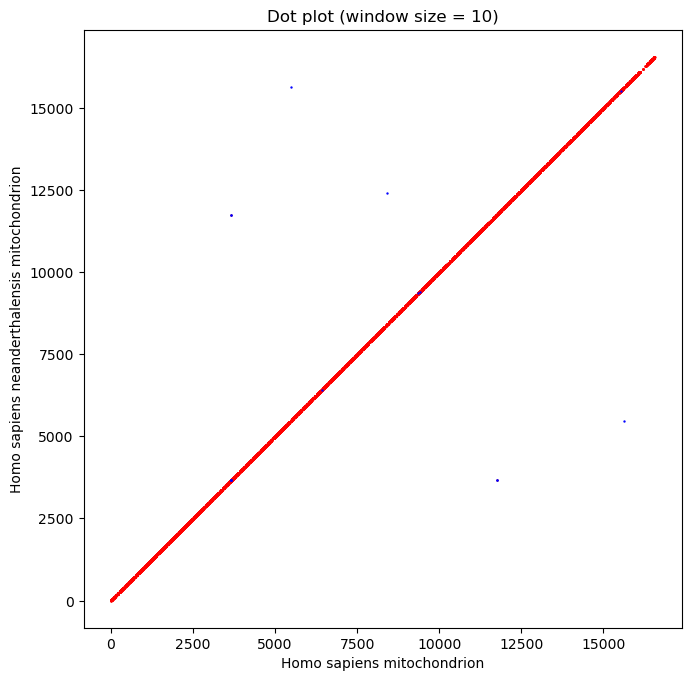

In [28]:
plt.figure(figsize=(7, 7))
plt.scatter(HS_coord_dir, HSA_coord_dir, s=2, marker='.', color='red', label="Directed")
plt.scatter(HS_coord_inv, HSA_coord_inv, s=2, marker='.', color='blue', label="Inverted")
plt.xlabel("Homo sapiens mitochondrion")
plt.ylabel("Homo sapiens neanderthalensis mitochondrion")
plt.title(f"Dot plot (window size = 10)")
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

**Вывод:** Митохондриальные геномы неандертальца и человека очень похожи — не наблюдается заметных делеций/инверсий. Это говорит о том, что в ходе эволюции не было особо заметных мутаций, что логично.